In [1]:
x = [1,2,3,4,5]
y = [50,55,65,70,75]

In [3]:
n = len(x)

In [7]:
n

5

In [5]:
mean_x = sum(x) / n
mean_y = sum(y) / n

In [ ]:
# list comprehensions skeleton
# [output, loop, condition]

In [9]:
numerator = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(n))
denominator = sum((x[i] - mean_x)**2 for i in range(n))

In [11]:
m = numerator / denominator

In [13]:
c = mean_y - m * mean_x

In [15]:
c

43.5

In [19]:
print(f'Regression Line y = {m}*x + {c}')

Regression Line y = 6.5*x + 43.5


In [23]:
predicted_marks = [m * i + c for i in x]
predicted_marks

[50.0, 56.5, 63.0, 69.5, 76.0]

In [25]:
for i in range(n):
    print(f"Actual marks {y[i]} and Predicted Marks {predicted_marks[i]}")

Actual marks 50 and Predicted Marks 50.0
Actual marks 55 and Predicted Marks 56.5
Actual marks 65 and Predicted Marks 63.0
Actual marks 70 and Predicted Marks 69.5
Actual marks 75 and Predicted Marks 76.0


In [27]:
import matplotlib.pyplot as plt

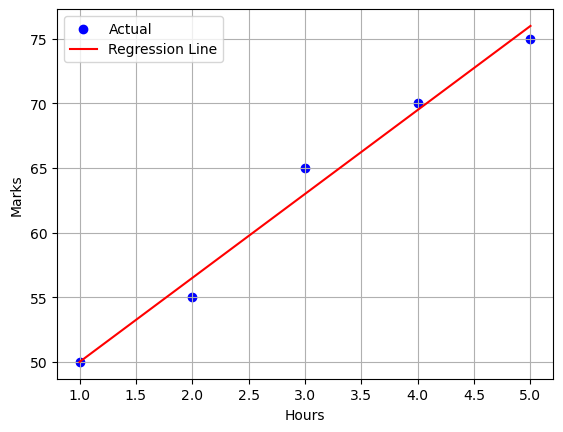

In [43]:
plt.scatter(x, y, color = 'blue', label = 'Actual')
plt.plot(x,predicted_marks, color= 'red', label = 'Regression Line')
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.legend()
plt.grid()
plt.show()

# House Price Prediction

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv(r"C:\Users\Abdullah\Downloads\Real_estate.csv")

In [8]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [14]:
df.isna().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [16]:
# Most imp metrics are: Mean,Min and Max
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


<Axes: xlabel='Avg. Area Income', ylabel='Count'>

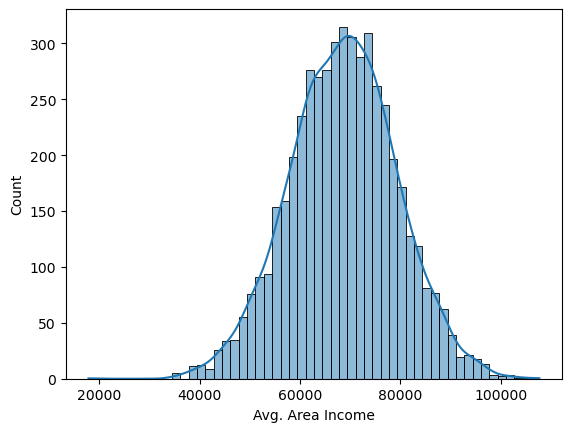

In [20]:
sns.histplot(df['Avg. Area Income'], kde = True)

<Axes: xlabel='Avg. Area House Age', ylabel='Count'>

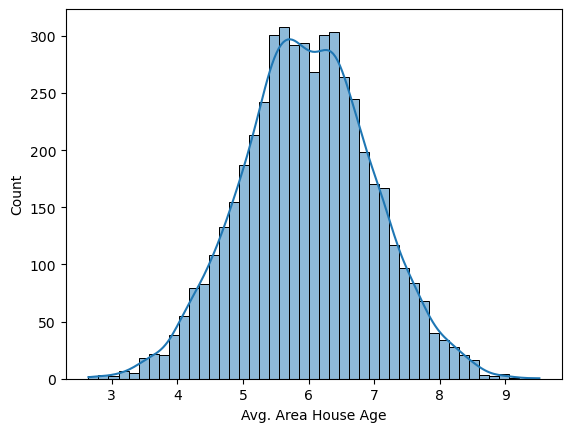

In [22]:
sns.histplot(df['Avg. Area House Age'], kde = True)

<Axes: xlabel='Avg. Area Number of Rooms', ylabel='Count'>

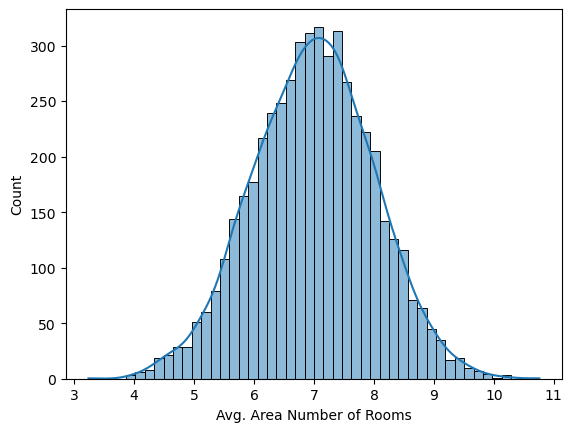

In [24]:
sns.histplot(df['Avg. Area Number of Rooms'], kde = True)

<Axes: xlabel='Avg. Area Number of Bedrooms', ylabel='Count'>

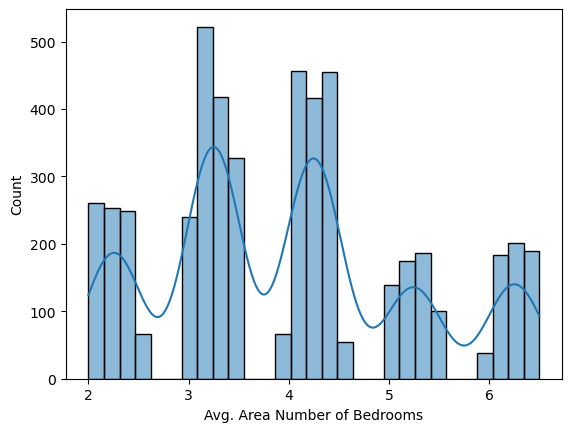

In [26]:
sns.histplot(df['Avg. Area Number of Bedrooms'], kde = True)

<Axes: xlabel='Area Population', ylabel='Count'>

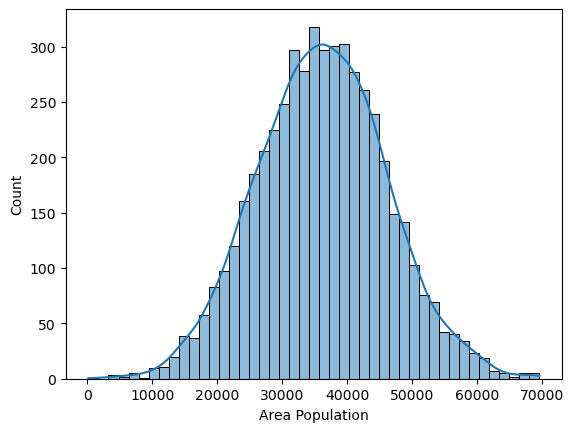

In [28]:
sns.histplot(df['Area Population'], kde = True)

<Axes: xlabel='Price', ylabel='Count'>

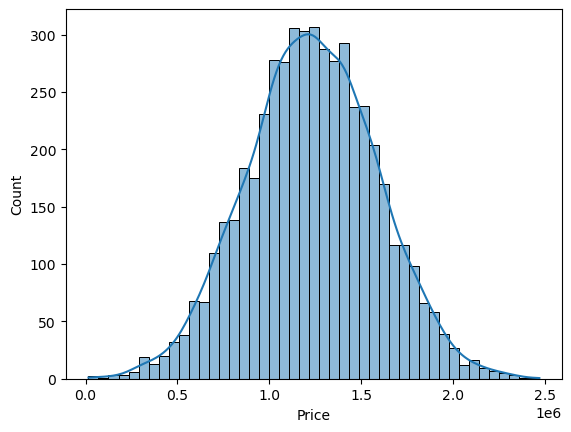

In [30]:
sns.histplot(df['Price'], kde = True)

In [38]:
cleaned_df = df.drop('Address', axis = 1)

In [40]:
cleaned_df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


In [42]:
cleaned_df.corr().style.background_gradient()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


In [46]:
X = cleaned_df.iloc[:,:-1]

In [48]:
X.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.45857,5.682861,7.009188,4.09,23086.80050
1,79248.64245,6.002900,6.730821,3.09,40173.07217
2,61287.06718,5.865890,8.512727,5.13,36882.15940
3,63345.24005,7.188236,5.586729,3.26,34310.24283
4,59982.19723,5.040555,7.839388,4.23,26354.10947


In [50]:
y = cleaned_df['Price']

In [52]:
y.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

In [44]:
from sklearn.model_selection import train_test_split

In [54]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y, test_size = 0.2)

In [56]:
#len(xtrain)



4000

In [58]:
len(ytest)

1000

In [60]:
from sklearn.linear_model import LinearRegression

In [62]:
lr = LinearRegression()  # Object creation

In [64]:
lr.fit(xtrain, ytrain)  # Training the model on training data

LinearRegression()

In [68]:
predict = lr.predict(xtest) # Doing prediction on test data

In [70]:
len(predict)

1000

In [72]:
predict

array([1639642.65357916, 1240920.00859562,  725922.19152215,
       1031192.61033117, 1641904.95783744, 1037455.22543223,
        753937.4795388 , 1372980.26337939, 1638059.67782124,
       2062400.62728871, 1285423.48104595,  855887.00493138,
       1477566.17828868,  974872.1596506 ,  969868.67395186,
       1476907.70225301, 1442796.35917617, 1811265.05717764,
       1739630.67435913, 1553711.16757388, 1124206.15532814,
        579903.53268649, 1547997.78635083, 1121502.31333456,
       1254380.18285023, 1406487.6247796 , 1240788.24385271,
        756017.09060789, 1291739.98774029, 1264642.63187888,
       1522586.38975219, 1545919.18547402, 1323488.40178236,
       1853576.4039445 , 1384751.10648272, 1269921.46984269,
       1671018.82182318, 1305827.33694758,  547175.81213623,
       1180330.61926366,  754261.23029052, 1637823.65617945,
       1513866.61509857, 1208932.83277915, 1661789.05220029,
       1132285.40034666, 1587635.68380145,  608090.43069933,
       1253576.64891723,

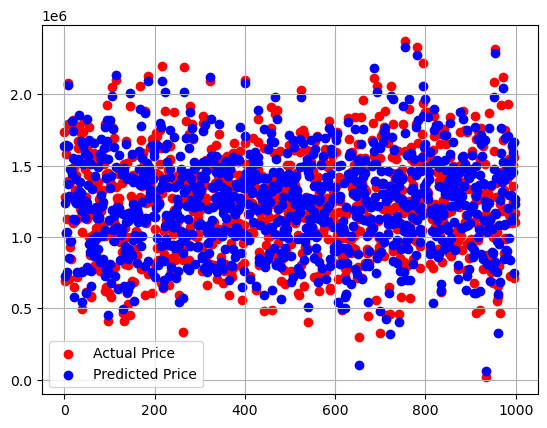

In [78]:
plt.scatter(range(len(ytest)), ytest, color = 'red', label = 'Actual Price')
plt.scatter(range(len(predict)), predict, color = 'blue', label = 'Predicted Price')
plt.grid()
plt.legend()
plt.show()

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [82]:
mae = mean_absolute_error(ytest,predict)
mse = mean_squared_error(ytest,predict)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, predict)

In [88]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2 Score: {r2}")

Mean Absolute Error: 81565.66229485923
Mean Squared Error: 10140645574.372353
Root Mean Squared Error: 100700.77246164675
R2 Score: 0.9188432608307271


# Polynomial Regression

In [5]:
salary_df = pd.read_csv(r"C:\Users\Abdullah\Downloads\Salary_vs_Experience (1).csv")

In [7]:
salary_df.head()

,Experience,Salary
0,8.12,61094.03
1,19.06,95469.20
2,14.91,82374.26
3,12.37,62728.10
4,3.96,33951.69


In [9]:
salary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Experience  500 non-null    float64
 1   Salary      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [11]:
salary_df.describe()

,Experience,Salary
count,500.000000,500.000000
mean,10.472580,60421.282820
std,5.675233,18428.947406
min,1.100000,12340.750000
25%,5.587500,49250.080000
50%,10.750000,62147.430000
75%,15.370000,73490.547500
max,19.870000,104400.860000


<Axes: xlabel='Salary', ylabel='Count'>

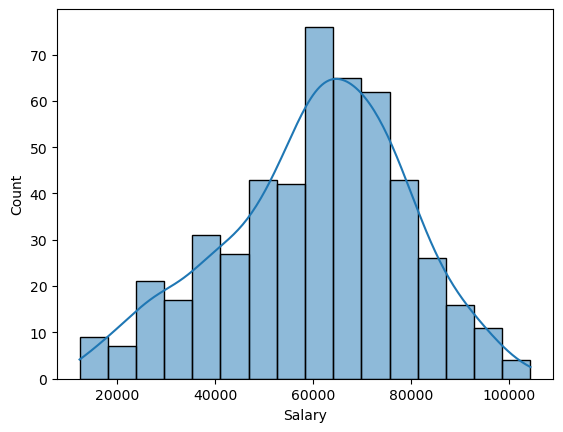

In [13]:
sns.histplot(salary_df['Salary'], kde = True)

<Axes: xlabel='Experience', ylabel='Count'>

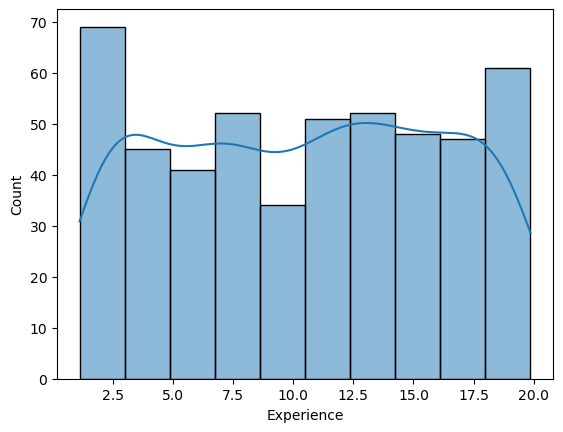

In [14]:
sns.histplot(salary_df['Experience'], kde = True)

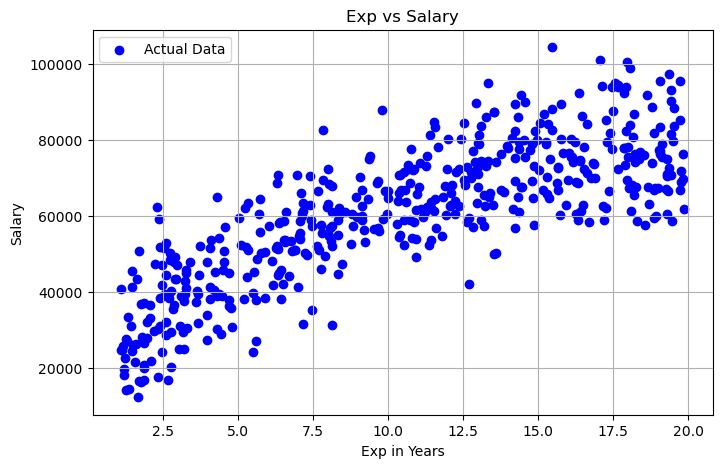

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(salary_df['Experience'], salary_df['Salary'], color ='blue', label='Actual Data')
plt.xlabel('Exp in Years')
plt.ylabel('Salary')
plt.title('Exp vs Salary')
plt.grid()
plt.legend()
plt.show()

In [19]:
salary_df.head()

,Experience,Salary
0,8.12,61094.03
1,19.06,95469.20
2,14.91,82374.26
3,12.37,62728.10
4,3.96,33951.69


In [21]:
salary_df[['Experience']]  # Dataframe

,Experience
0,8.12
1,19.06
2,14.91
3,12.37
4,3.96
...,...
495,7.71
496,12.09
497,2.48
498,19.51


In [23]:
salary_df['Experience']  # series

0       8.12
1      19.06
2      14.91
3      12.37
4       3.96
       ...  
495     7.71
496    12.09
497     2.48
498    19.51
499    19.74
Name: Experience, Length: 500, dtype: float64

In [25]:
X = salary_df[['Experience']].values  # convert df into numpy array

In [27]:
X

array([[ 8.12],
       [19.06],
       [14.91],
       [12.37],
       [ 3.96],
       [ 3.96],
       [ 2.1 ],
       [17.46],
       [12.42],
       [14.45],
       [ 1.39],
       [19.43],
       [16.82],
       [ 5.03],
       [ 4.45],
       [ 4.48],
       [ 6.78],
       [10.97],
       [ 9.21],
       [ 6.53],
       [12.63],
       [ 3.65],
       [ 6.55],
       [ 7.96],
       [ 9.67],
       [15.92],
       [ 4.79],
       [10.77],
       [12.26],
       [ 1.88],
       [12.54],
       [ 4.24],
       [ 2.24],
       [19.03],
       [19.35],
       [16.36],
       [ 6.79],
       [ 2.86],
       [14.  ],
       [ 9.36],
       [ 3.32],
       [10.41],
       [ 1.65],
       [18.28],
       [ 5.92],
       [13.59],
       [ 6.92],
       [10.88],
       [11.39],
       [ 4.51],
       [19.42],
       [15.73],
       [18.85],
       [18.  ],
       [12.36],
       [18.52],
       [ 2.68],
       [ 4.72],
       [ 1.86],
       [ 7.18],
       [ 8.38],
       [ 6.16],
       [

In [29]:
y = salary_df[['Salary']].values

In [31]:
from sklearn.linear_model import LinearRegression

In [33]:
lr = LinearRegression()

In [35]:
lr.fit(X,y)

LinearRegression()

In [37]:
ypred = lr.predict(X)

In [39]:
ypred

array([[54246.11793641],
       [82961.95494363],
       [72068.83578642],
       [65401.7218926 ],
       [43326.7502993 ],
       [43326.7502993 ],
       [38444.53303847],
       [78762.19816013],
       [65532.96429208],
       [70861.40571116],
       [36580.89096579],
       [83933.14869982],
       [77082.29544673],
       [46135.33764827],
       [44612.92581425],
       [44691.67125394],
       [50728.82163023],
       [61726.93470703],
       [57107.20224518],
       [50072.6096328 ],
       [66084.18236992],
       [42513.04742249],
       [50125.1065926 ],
       [53826.14225806],
       [58314.63232043],
       [74719.932256  ],
       [45505.37413074],
       [61201.96510909],
       [65112.98861373],
       [37867.06648074],
       [65847.94605085],
       [44061.70773641],
       [38812.01175703],
       [82883.20950394],
       [83723.16086064],
       [75874.86537147],
       [50755.07011012],
       [40439.41751064],
       [69680.2241158 ],
       [57500.92944363],


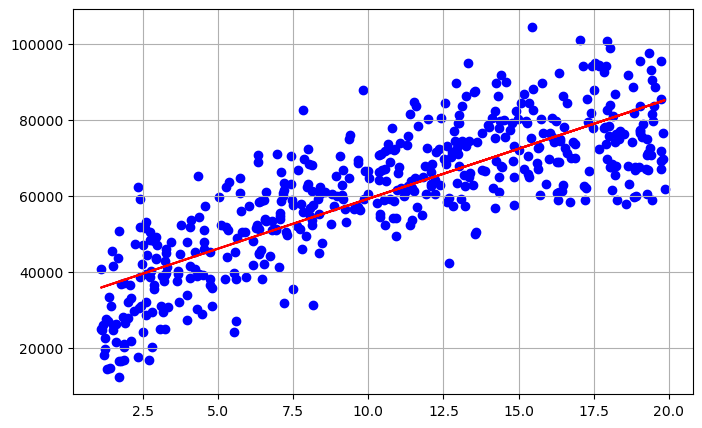

In [44]:
plt.figure(figsize=(8,5))
plt.scatter(X,y, color = 'blue', label = 'Actual Data')
plt.plot(X, ypred, color = 'red', label = 'Linear Regression')
plt.grid()
plt.show()

In [46]:
# Performance of Linear Regression is poor because the error is high

In [48]:
# Actual data -> Polynomial Expression -> Linear Regression

In [41]:
from sklearn.preprocessing import PolynomialFeatures

In [43]:
poly = PolynomialFeatures(degree = 2)

In [45]:
poly

PolynomialFeatures()

In [53]:
X_poly = poly.fit_transform(X)  # Converting to polynomial Expression

In [55]:
X_poly

array([[  1.    ,   8.12  ,  65.9344],
       [  1.    ,  19.06  , 363.2836],
       [  1.    ,  14.91  , 222.3081],
       ...,
       [  1.    ,   2.48  ,   6.1504],
       [  1.    ,  19.51  , 380.6401],
       [  1.    ,  19.74  , 389.6676]])

In [57]:
poly_lr = LinearRegression()

In [59]:
poly_lr.fit(X_poly,y)

LinearRegression()

In [61]:
ypred_poly = poly_lr.predict(X_poly)

In [63]:
ypred_poly

array([[58304.96725829],
       [76509.43835553],
       [73847.61583812],
       [69659.2379325 ],
       [41922.04365832],
       [41922.04365832],
       [32910.60335579],
       [76097.67242724],
       [69760.4369593 ],
       [73233.19203142],
       [29195.93884923],
       [76494.88136651],
       [75717.05503932],
       [46633.87446046],
       [44122.60062312],
       [44254.97912242],
       [53596.89141848],
       [66519.93180889],
       [61735.75646141],
       [52658.65255005],
       [70177.24969839],
       [40492.50388004],
       [52734.40445436],
       [57771.24365883],
       [63076.22925586],
       [74973.06974143],
       [45607.01624365],
       [66023.26508217],
       [69433.94938025],
       [31775.8160473 ],
       [70000.24222914],
       [43188.36050636],
       [33625.15011224],
       [76508.81136106],
       [76501.52291929],
       [75367.27885983],
       [53634.02939353],
       [36718.60517384],
       [72570.45146287],
       [62179.87040739],


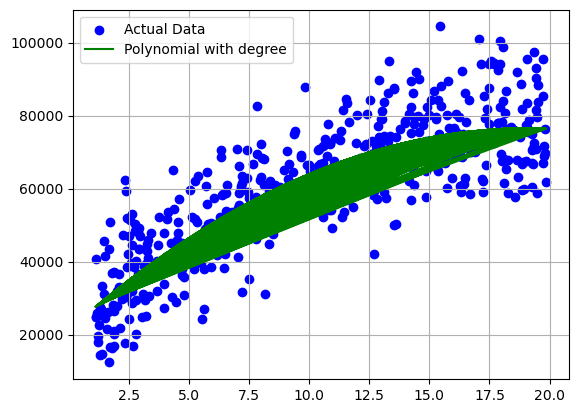

In [65]:
plt.scatter(X, y , color='blue',label = 'Actual Data')
plt.plot(X, ypred_poly, color = 'green', label = 'Polynomial with degree')
plt.legend()
plt.grid()
plt.show()

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [69]:
def evaluate_model(name, ytrue,ypred):
    mae = mean_absolute_error(ytrue, ypred)
    mse = mean_squared_error(ytrue, ypred)
    rmse = np.sqrt(mse)
    r2 = r2_score(ytrue, ypred)
    return pd.Series({
        'Model':name,
        'MAE':mae,
        "MSE":mse,
        'RMSE':rmse,
        'R2 score':r2
    })

In [71]:
results = pd.DataFrame([
    evaluate_model('Linear Regression',y, ypred),
    evaluate_model('Polynomial Regression',y, ypred_poly)

])

In [73]:
results

,Model,MAE,MSE,RMSE,R2 score
0,Linear Regression,8771.660815,1.174813e+08,10838.877051,0.653393
1,Polynomial Regression,7984.889159,1.000323e+08,10001.616633,0.704873


# Assumptions in Linear Regression

1.Linearity - the relationship between X(independent) and Y(dependent) variable must be linear

```Eg: When X increases Y must increase or decrease```

2. Indepence Error (residual) - residuals or errors should be independent of each other

   DW Test

3. Homoskedasticity - The error should have a constant variance for all values of X (matlab jho spread hai voh constant hona chahiye).

4. Normality of Residual - Residuals must follow a normally distributed curve (Q-Q plot)

5. No Multicollinearity - Independent variable X should not be highly co-related with each other

6. No Extreme Outliers - Outliers can distort the performance of the model

**Multiple Linear Regression Model**

In [6]:
df = pd.read_csv(r"C:\Users\Abdullah\Downloads\Employee_Salary.csv")
df.head()

,Experience,Age,Education,Job_Grade,Performance,Cost_Index,Gender,Salary
0,7,28,3,2,1,1,0,113399.034010
1,20,39,2,5,1,1,1,150341.142577
2,15,48,1,4,2,1,1,139929.416811
3,11,55,1,2,1,2,0,135507.589615
4,8,48,1,9,2,2,0,163001.189508


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Experience   1000 non-null   int64  
 1   Age          1000 non-null   int64  
 2   Education    1000 non-null   int64  
 3   Job_Grade    1000 non-null   int64  
 4   Performance  1000 non-null   int64  
 5   Cost_Index   1000 non-null   int64  
 6   Gender       1000 non-null   int64  
 7   Salary       1000 non-null   float64
dtypes: float64(1), int64(7)
memory usage: 62.6 KB


In [20]:
df.isna().sum()

Experience     0
Age            0
Education      0
Job_Grade      0
Performance    0
Cost_Index     0
Gender         0
Salary         0
dtype: int64

In [22]:
df.describe()

,Experience,Age,Education,Job_Grade,Performance,Cost_Index,Gender,Salary
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.136000,40.757000,1.645000,5.015000,3.044000,1.788000,0.505000,144226.052902
std,5.895953,10.948325,0.717977,2.571262,1.401438,0.754735,0.500225,27515.610284
min,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,0.000000,66056.443333
25%,5.000000,31.000000,1.000000,3.000000,2.000000,1.000000,0.000000,124779.061011
50%,10.000000,41.000000,2.000000,5.000000,3.000000,2.000000,1.000000,143835.926051
75%,15.000000,50.000000,2.000000,7.000000,4.000000,2.000000,1.000000,164177.708842
max,20.000000,59.000000,3.000000,9.000000,5.000000,3.000000,1.000000,214079.287601


In [24]:
df.columns

Index(['Experience', 'Age', 'Education', 'Job_Grade', 'Performance',
       'Cost_Index', 'Gender', 'Salary'],
      dtype='object')

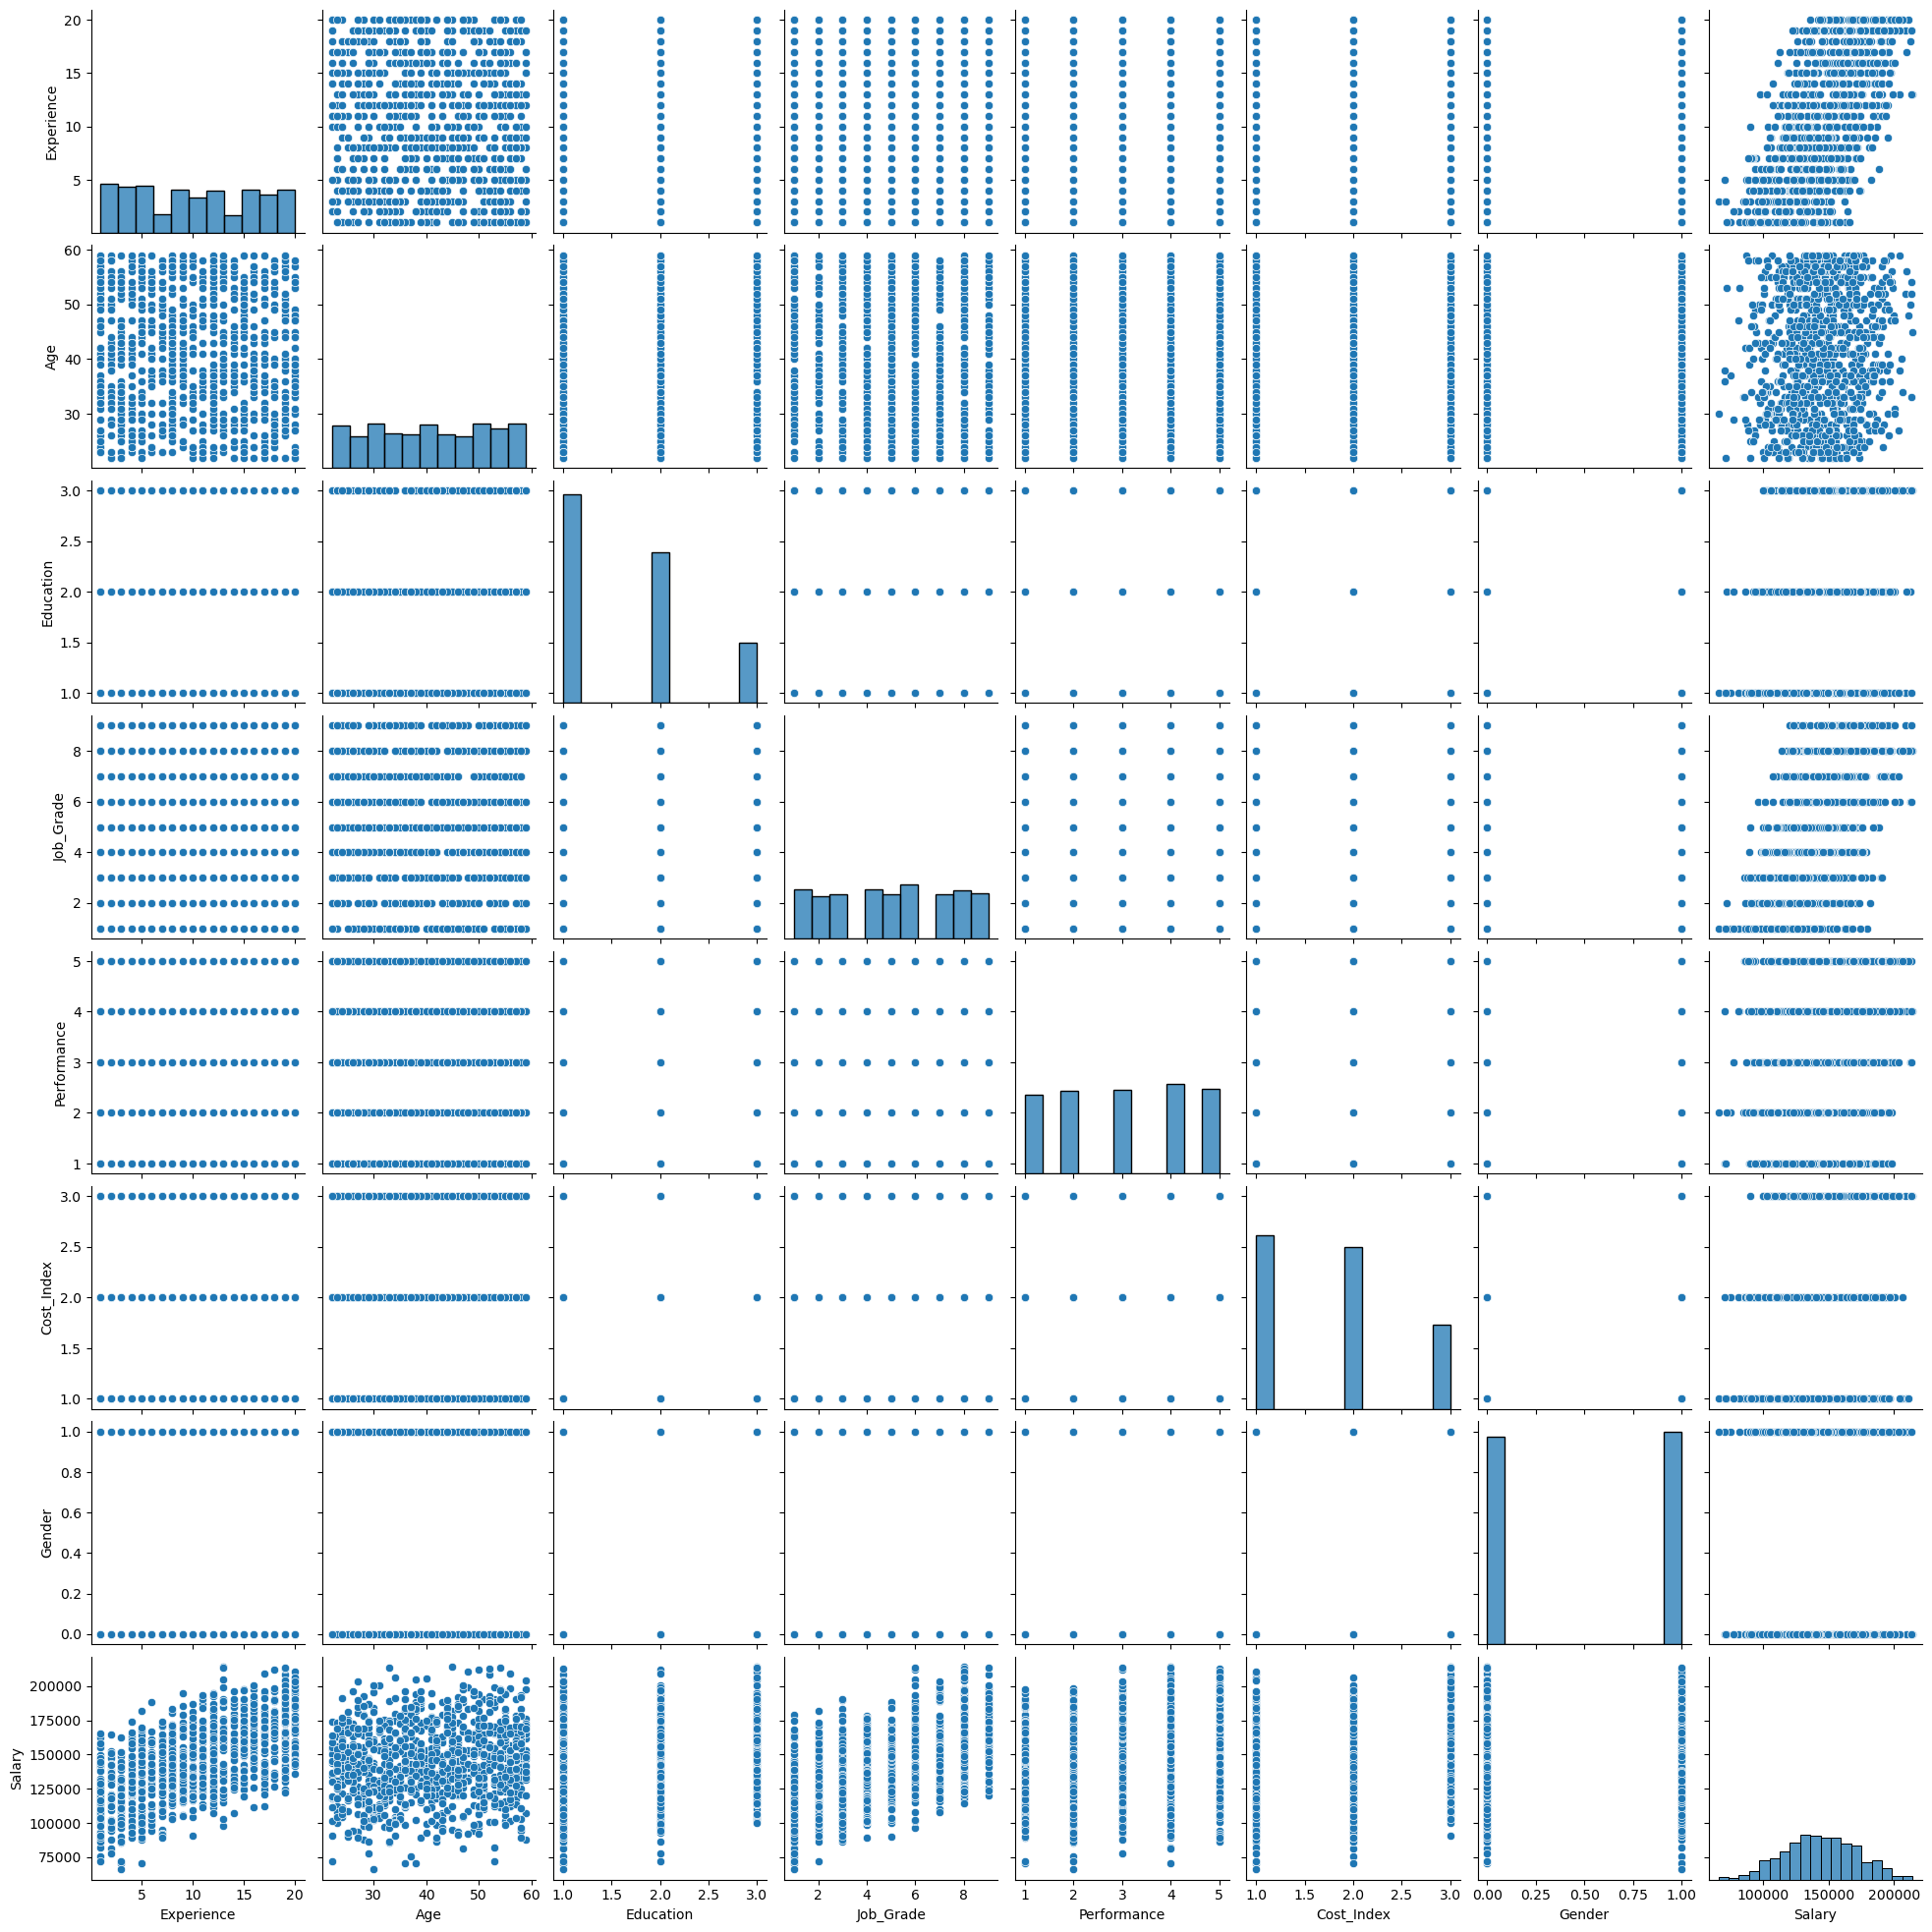

In [28]:
sns.pairplot(df[['Experience', 'Age', 'Education', 'Job_Grade', 'Performance','Cost_Index', 'Gender', 'Salary']])

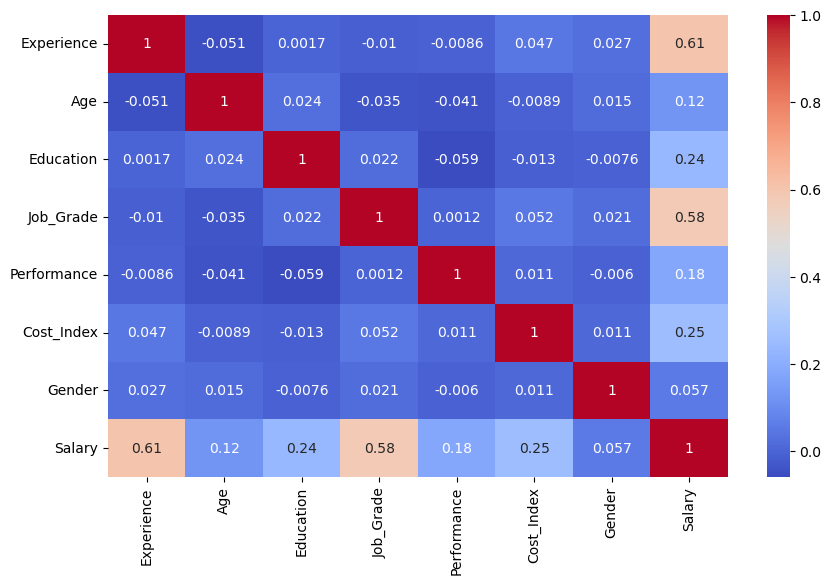

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm')
plt.show()

In [32]:
df.columns

Index(['Experience', 'Age', 'Education', 'Job_Grade', 'Performance',
       'Cost_Index', 'Gender', 'Salary'],
      dtype='object')

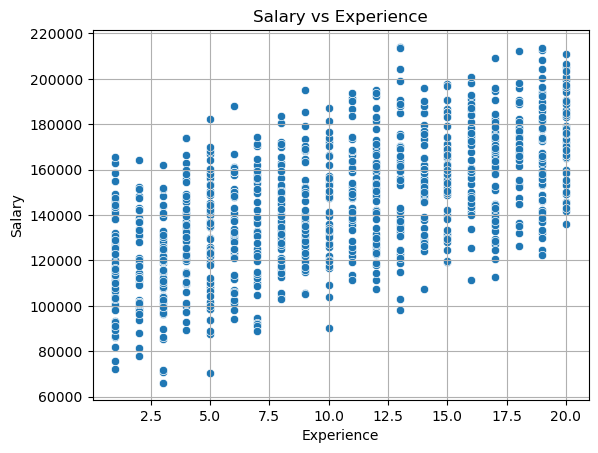

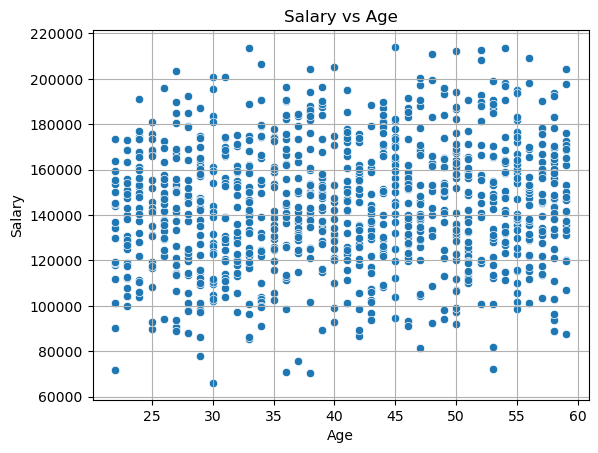

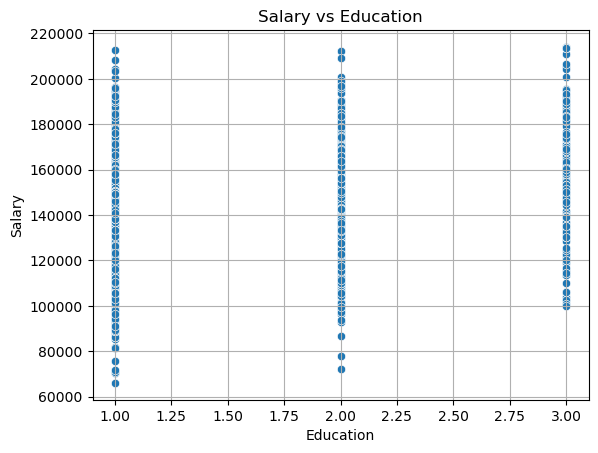

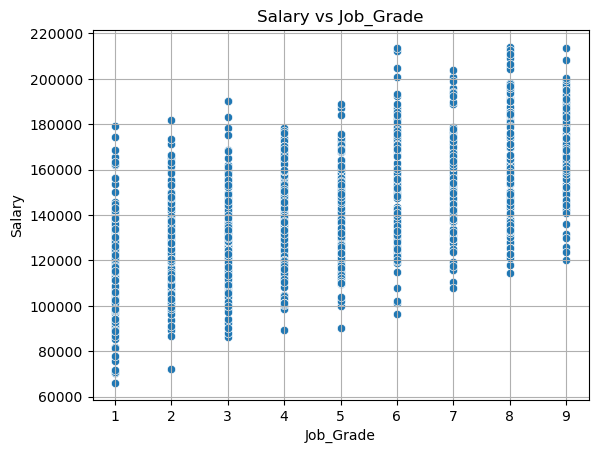

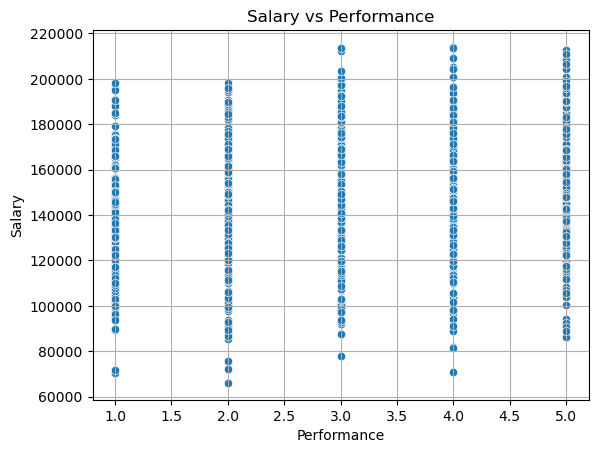

In [34]:
for col in ['Experience', 'Age', 'Education', 'Job_Grade', 'Performance']:
    sns.scatterplot(x=df[col], y=df['Salary'])
    plt.title(f"Salary vs {col}")
    plt.grid()
    plt.show()

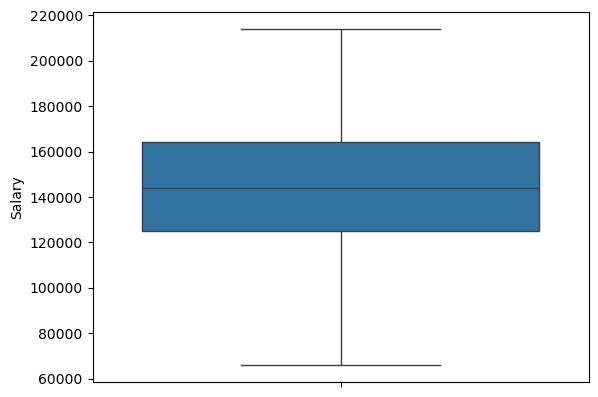

In [40]:
sns.boxplot(df['Salary'])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

In [10]:
df.columns

Index(['Experience', 'Age', 'Education', 'Job_Grade', 'Performance',
       'Cost_Index', 'Gender', 'Salary'],
      dtype='object')

In [12]:
X =  df[['Experience', 'Age', 'Education', 'Job_Grade', 'Performance','Cost_Index', 'Gender']] #Features
y = df['Salary'] #Prediction

In [14]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y, test_size=0.2,random_state=42)

In [52]:
len(xtrain)

800

In [54]:
len(xtest)

200

In [16]:
from sklearn.linear_model import LinearRegression

In [20]:
lr = LinearRegression() #Object creation

In [22]:
lr.fit(xtrain,ytrain) #Training the model

LinearRegression()

In [24]:
ypred = lr.predict(xtest)

In [26]:
ypred

array([128679.18460373, 147433.01898784, 115291.36524577, 125546.52442955,
       147619.00784781, 118532.65978733, 117541.10876693, 141340.08271322,
       166315.56178001, 129377.41939279, 129442.50144619, 146173.67511459,
       151507.12586767, 178457.96815703, 190970.18354639, 177097.17863157,
       164038.13220145, 121995.88907167, 145583.81447156, 122814.64371612,
       122648.58577966, 118024.9533898 , 123761.74027203, 151777.19414851,
       132969.0322811 , 108093.1617305 , 163470.77014968, 155165.40621355,
       146964.92248462, 167826.72445143, 139753.21263219, 147537.07705341,
       143605.56465668, 153854.33875506, 144059.89460141, 153796.29946739,
        96587.36525772, 126139.22810122, 141914.72351141, 150419.58823021,
       141414.34112002, 119942.76624177, 140904.28058765, 152495.78131474,
       178307.57372276, 191776.87414067, 145917.80444833, 175295.51373788,
       163482.28906942, 156234.44382109, 158815.94951741, 135223.17354192,
       164388.33819585, 1

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
print("MAE", mean_absolute_error(ytest,ypred))
print("MSE", mean_squared_error(ytest,ypred))
print("R2", r2_score(ytest,ypred))

MAE 7735.084535834429
MSE 92764108.06101963
R2 0.8704813186082184


In [34]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":lr.coef_
})
coef

,Feature,Coefficient
0,Experience,2864.272622
1,Age,455.802997
2,Education,9217.908850
3,Job_Grade,6215.896383
4,Performance,3973.565028
5,Cost_Index,7209.433171
6,Gender,1753.750380


**Ordinary Least Square**

OLS finds the line/plane that minimizes the SUM of SQUARED ERRORS between the actual value and the predicted value

$$
SSE = /sum(/hat{y - y^}) ^2
$$

OLS tries to make SSE as small as possible

In [42]:
import statsmodels.api as sm

In [46]:
y

0      113399.034010
1      150341.142577
2      139929.416811
3      135507.589615
4      163001.189508
           ...      
995    140701.010940
996    176234.636555
997    149174.497769
998    105635.539484
999    117661.573589
Name: Salary, Length: 1000, dtype: float64

In [48]:
X_sm = sm.add_constant(X)

In [52]:
model_ols = sm.OLS(y,X_sm).fit()

In [54]:
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     948.3
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        09:37:43   Log-Likelihood:                -10621.
No. Observations:                1000   AIC:                         2.126e+04
Df Residuals:                     992   BIC:                         2.130e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.556e+04   1976.043     12.935      0.000    2.17e+04    2.94e+04
Experience   2860.9873     53.585     53.392      0.000    2755.834    2966.140
Age           452.9893     28.864     15.694      0.000     396.348     509.631
Education    8975.9580    439.790     20.410      0.000    8112.933    9838.983
Job_Grade    6157.3861    122.825     50.131      0.000    5916.359    6398.413
Performance  3977.7585    225.372     17.650      0.000    3535.498    4420.019
Cost_Index   7120.6009    418.497     17.015      0.000    6299.359    7941.843
Gender       1426.2901    630.255      2.263      0.024     189.504    2663.076
==============================================================================
Omnibus:                        3.067   Durbin-Watson:                   2.062
Prob(Omnibus):                  0.216   Jarque-Bera (JB):                3.044
Skew:                          -0.086   Prob(JB):                        0.218
Kurtosis:                       3.209   Cond. No.                         277.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

`Overfitting` : The model has learned patterns and noise from the training data, so it performs really well on the train data but fails poorly on unknown data

`Underfit` : The model is unable to capture or learn the underlying patterns from the known data.

In [58]:
# Checking r2 score for determining whether the model is overfit and underfit
train_prediction = lr.predict(xtrain)
test_prediction = lr.predict(xtest)

r2_score_training = r2_score(ytrain,train_prediction)
r2_score_testing = r2_score(ytest,test_prediction)

print("Training Score", r2_score_training)
print("testing Score",r2_score_testing)  # Indicates a good model because training and testing score are on the same line

Training Score 0.8696990829398078
testing Score 0.8704813186082184


L1 Regularization (Lasso Regression) : Shrinks the coefficient 

L2 Regularization (Ridge Regression) : Tries to penalise the features

**L1 Technique Lasso Regression (Shrinking of coefficient)**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv(r"C:\Users\Abdullah\OneDrive\Documents\ML Dataset\Lasso_Regression_Data.csv")

In [8]:
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,3.662741
1,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,0.002422
2,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,6.373778
3,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,-6.758320
4,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,3.309353


In [10]:
df.corr()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
Feature_1,1.000000,-0.084420,0.063465,-0.024950,0.003329,0.137987,-0.026304,0.056041,0.101534,-0.058193,0.846402
Feature_2,-0.084420,1.000000,0.085749,-0.072643,0.099239,-0.144599,-0.207891,0.010799,-0.189630,-0.228326,-0.556035
Feature_3,0.063465,0.085749,1.000000,0.029762,0.143809,-0.063415,-0.034737,-0.013716,-0.071440,0.136171,-0.003028
Feature_4,-0.024950,-0.072643,0.029762,1.000000,-0.045140,0.020070,0.171421,-0.053745,0.236767,0.152160,0.016371
Feature_5,0.003329,0.099239,0.143809,-0.045140,1.000000,-0.060003,-0.110816,0.026053,0.084423,0.054559,-0.075347
Feature_6,0.137987,-0.144599,-0.063415,0.020070,-0.060003,1.000000,-0.066022,0.037226,-0.020233,-0.062478,0.203077
Feature_7,-0.026304,-0.207891,-0.034737,0.171421,-0.110816,-0.066022,1.000000,0.023378,0.066567,-0.012753,0.044072
Feature_8,0.056041,0.010799,-0.013716,-0.053745,0.026053,0.037226,0.023378,1.000000,0.025111,0.125035,0.035666
Feature_9,0.101534,-0.189630,-0.071440,0.236767,0.084423,-0.020233,0.066567,0.025111,1.000000,-0.031783,0.181196
Feature_10,-0.058193,-0.228326,0.136171,0.152160,0.054559,-0.062478,-0.012753,0.125035,-0.031783,1.000000,0.048870


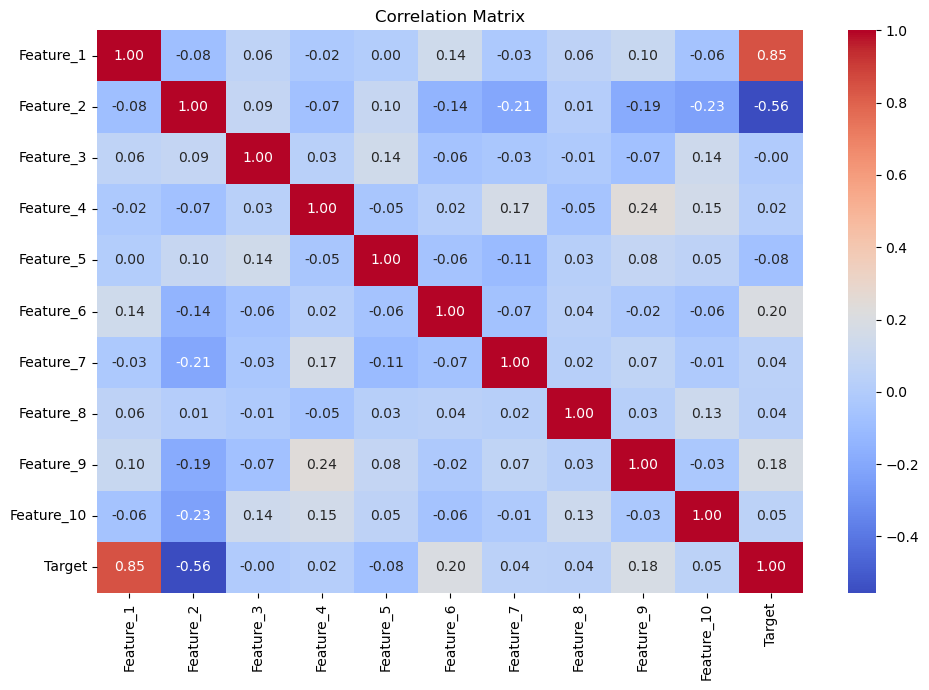

In [12]:
corr_matrix = df.corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   100 non-null    float64
 1   Feature_2   100 non-null    float64
 2   Feature_3   100 non-null    float64
 3   Feature_4   100 non-null    float64
 4   Feature_5   100 non-null    float64
 5   Feature_6   100 non-null    float64
 6   Feature_7   100 non-null    float64
 7   Feature_8   100 non-null    float64
 8   Feature_9   100 non-null    float64
 9   Feature_10  100 non-null    float64
 10  Target      100 non-null    float64
dtypes: float64(11)
memory usage: 8.7 KB


In [14]:
from sklearn.model_selection import train_test_split

In [17]:
X = df.drop('Target', axis = 1)
y = df['Target']

In [20]:
X

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560
1,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304
2,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694
3,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861
4,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040
...,...,...,...,...,...,...,...,...,...,...
95,-0.241236,0.352055,-1.251539,1.443765,-0.082151,1.117296,0.342725,0.456753,0.569767,0.447709
96,0.642723,1.329153,0.196521,0.709004,-0.089736,1.440117,-0.676392,1.800940,-0.040158,-1.430775
97,0.128104,-0.681052,0.840644,-0.652624,-0.446183,-1.889541,-0.452306,-2.423879,-1.583903,0.760415
98,0.785800,0.425458,-0.966976,-0.047711,-0.003603,-1.158365,1.503398,0.877362,-0.220964,0.026886


In [22]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y, test_size=0.2, random_state=42)

In [24]:
df['Feature_1'].min()

-1.9187712152990413

In [26]:
df['Feature_1'].max()

2.5269324258736217

**Scalarization** : It is performed so that ML does not give priority to some (jaise only to negative numbers agar negative numbers zyada hai toh) because afterall ML works on patterns

MinMax Scaler

Standard Scaler

In [29]:
from sklearn.preprocessing import StandardScaler

In [31]:
# Formula for Standard scaler is X-Xmean/std deviation
sc = StandardScaler() # Object Creation

In [33]:
xtrain_scaled = sc.fit_transform(xtrain) # Scaling xtrain data

In [35]:
x_test_scaled = sc.fit_transform(xtest)

In [37]:
xtrain_scaled

array([[ 0.12430461, -0.22674169,  1.21013478,  0.08755065,  0.22054752,
        -0.34606345, -0.45891398, -0.51343119,  0.40094143, -0.48264034],
       [ 2.8550114 , -0.57509299, -0.41524553,  0.88460411,  0.540363  ,
         1.88482415,  0.69024501, -0.43170663,  0.61082659,  1.05404195],
       [-1.00980934, -0.13746827, -3.11420089, -1.2031003 , -0.32767173,
        -1.17171907,  1.81468282, -1.6261839 , -0.49174999,  0.07160738],
       [ 2.33335794,  1.54756707, -0.17939063,  0.81134196,  0.50644313,
         1.41261095, -0.97080924,  0.7343203 ,  1.11121682, -1.82651199],
       [-0.37650378,  0.99419313, -0.99550218,  0.45241324,  0.45788432,
        -0.24498779,  0.41377453, -1.4264876 ,  0.96744695, -0.24547855],
       [ 0.30770968,  0.23946299, -0.60216897,  0.06517822,  0.17918271,
        -0.6448287 ,  2.06495142,  0.49760144, -1.29539909,  0.5998246 ],
       [-1.75672868, -0.63869848,  0.06993297, -0.12181061, -0.5111302 ,
         0.67597474, -1.08094583, -0.18975178

In [39]:
from sklearn.linear_model import LinearRegression

In [41]:
lr = LinearRegression()

In [43]:
lr.fit(xtrain_scaled,ytrain) # Training scaled data

LinearRegression()

In [45]:
lr.predict(x_test_scaled)

array([-5.00257137,  5.8459349 , -5.99881007, -4.38293551,  0.12370523,
       -6.13371131, 12.90283073,  3.69692737, -6.63747599,  0.65329686,
        3.26682653, -3.6905075 ,  1.76304146,  0.86129361,  1.49941878,
        1.41600828, -4.26134125,  2.98477802,  4.27347055, -5.73384511])

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [56]:
# Checking r2 score for determining whether the model is overfit and underfit
train_prediction = lr.predict(xtrain_scaled)
test_prediction = lr.predict(x_test_scaled)

r2_score_training = r2_score(ytrain,train_prediction)
r2_score_testing = r2_score(ytest,test_prediction)

print("Training Score", r2_score_training)
print("testing Score",r2_score_testing)  

Training Score 0.9575149792715418
testing Score 0.8216825705899533


In [58]:
# Overfit scenario above

**Handling Overfitting with Lasso**

Lasso : Least Absolute Shrinkage and selection operator

It is a technique in Liner Regression which tries to reduce the overfit

- can eliminate less important features

alpha : regularization strength (strict hone ka number - basically kitna strict rahega)

hyper parameter tuning

In [61]:
from sklearn.linear_model import Lasso

In [63]:
ls = Lasso(alpha = 0.1)

In [65]:
ls.fit(xtrain_scaled, ytrain)

Lasso(alpha=0.1)

In [67]:
ypred_ls = ls.predict(x_test_scaled)

In [69]:
ypred_ls

array([-4.58231352,  5.46614354, -6.12548501, -4.17681453,  0.14204626,
       -6.21126788, 12.59217371,  3.5926949 , -6.18111731,  0.73261042,
        3.20431621, -3.4347518 ,  1.79275023,  0.84800659,  1.12563332,
        1.10069902, -4.11041243,  2.8492532 ,  4.10366093, -5.28149162])

In [71]:
# Checking r2 score for determining whether the model is overfit and underfit
train_prediction = ls.predict(xtrain_scaled)
test_prediction = ls.predict(x_test_scaled)

r2_score_training = r2_score(ytrain,train_prediction)
r2_score_testing = r2_score(ytest,test_prediction)

print("Training Score", r2_score_training)
print("testing Score",r2_score_testing)  

Training Score 0.954325108434983
testing Score 0.8310648914198013


In [75]:
# hyper parameter tuning (cross validation)

In [81]:
# logspace(startnum,endnum,kitne numbers chahiye)
alpha_data = np.logspace(-2,2,20)

In [83]:
alpha_data

array([1.00000000e-02, 1.62377674e-02, 2.63665090e-02, 4.28133240e-02,
       6.95192796e-02, 1.12883789e-01, 1.83298071e-01, 2.97635144e-01,
       4.83293024e-01, 7.84759970e-01, 1.27427499e+00, 2.06913808e+00,
       3.35981829e+00, 5.45559478e+00, 8.85866790e+00, 1.43844989e+01,
       2.33572147e+01, 3.79269019e+01, 6.15848211e+01, 1.00000000e+02])

In [85]:
from sklearn.model_selection import cross_val_score

In [87]:
lasso_score = []
for i in alpha_data:
    print("For alpha value",i)
    ls = Lasso(alpha = i)
    ls.fit(xtrain_scaled, ytrain)
    ypred_ls = ls.predict(x_test_scaled)
   
    train_prediction = ls.predict(xtrain_scaled)
    test_prediction = ls.predict(x_test_scaled)
    
    r2_score_training = r2_score(ytrain,train_prediction)
    r2_score_testing = r2_score(ytest,test_prediction)
    
    print("Training Score", r2_score_training)
    print("testing Score",r2_score_testing)
    print("--"*50)
    

For alpha value 0.01
Training Score 0.957466497633938
testing Score 0.8233016212881596
----------------------------------------------------------------------------------------------------
For alpha value 0.016237767391887217
Training Score 0.9573992384405063
testing Score 0.8239852555001889
----------------------------------------------------------------------------------------------------
For alpha value 0.026366508987303583
Training Score 0.9572253554682455
testing Score 0.824970124538186
----------------------------------------------------------------------------------------------------
For alpha value 0.04281332398719394
Training Score 0.9567681463121154
testing Score 0.8264350444069065
----------------------------------------------------------------------------------------------------
For alpha value 0.06951927961775606
Training Score 0.9556982169224172
testing Score 0.8286903913704871
------------------------------------------------------------------------------------------------

In [93]:
# 2nd technique to handle overfitting with Ridge regresison

In [95]:
from sklearn.linear_model import Ridge

In [101]:
lasso_score = []
for i in alpha_data:
    print("For alpha value",i)
    ls = Ridge(alpha = i)
    ls.fit(xtrain_scaled, ytrain)
    ypred_ls = ls.predict(x_test_scaled)
   
    train_prediction = ls.predict(xtrain_scaled)
    test_prediction = ls.predict(x_test_scaled)
    
    r2_score_training = r2_score(ytrain,train_prediction)
    r2_score_testing = r2_score(ytest,test_prediction)
    
    print("Training Score", r2_score_training)
    print("testing Score",r2_score_testing)
    print("--"*19)

For alpha value 0.01
Training Score 0.9575149622172626
testing Score 0.8217234014500338
--------------------------------------
For alpha value 0.016237767391887217
Training Score 0.9575149343145004
testing Score 0.8217488369906252
--------------------------------------
For alpha value 0.026366508987303583
Training Score 0.9575148607746277
testing Score 0.8217900833542291
--------------------------------------
For alpha value 0.04281332398719394
Training Score 0.9575146670038647
testing Score 0.8218569126403207
--------------------------------------
For alpha value 0.06951927961775606
Training Score 0.9575141566461821
testing Score 0.8219650451947544
--------------------------------------
For alpha value 0.11288378916846889
Training Score 0.9575128133530015
testing Score 0.822139620334714
--------------------------------------
For alpha value 0.18329807108324356
Training Score 0.9575092815491292
testing Score 0.8224204447823019
--------------------------------------
For alpha value 0.29